In [1]:
import pandas as pd
import numpy as np

data = {
    "size_sqft": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2700, 3000],
    "bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "price": [150000, 180000, 200000, 240000, 280000, 310000, 330000, 360000, 400000, 450000]
}

df = pd.DataFrame(data)

In [2]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

First 5 rows:
   size_sqft  bedrooms   price
0        800         2  150000
1       1000         2  180000
2       1200         3  200000
3       1500         3  240000
4       1800         3  280000

Last 5 rows:
   size_sqft  bedrooms   price
5       2000         4  310000
6       2200         4  330000
7       2500         4  360000
8       2700         5  400000
9       3000         5  450000


In [3]:
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   size_sqft  10 non-null     int64
 1   bedrooms   10 non-null     int64
 2   price      10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes
None

Statistical Summary:
         size_sqft   bedrooms          price
count    10.000000  10.000000      10.000000
mean   1870.000000   3.500000  290000.000000
std     743.938468   1.080123   98319.208025
min     800.000000   2.000000  150000.000000
25%    1275.000000   3.000000  210000.000000
50%    1900.000000   3.500000  295000.000000
75%    2425.000000   4.000000  352500.000000
max    3000.000000   5.000000  450000.000000


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())

df.fillna(df.mean(), inplace=True)


Missing Values:
size_sqft    0
bedrooms     0
price        0
dtype: int64


In [5]:
X = df[["size_sqft", "bedrooms"]]
y = df["price"]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Features:\n", X_scaled[:5])



Scaled Features:
 [[-1.51609183 -1.46385011]
 [-1.23271018 -1.46385011]
 [-0.94932853 -0.48795004]
 [-0.52425605 -0.48795004]
 [-0.09918358 -0.48795004]]


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_simple = df[["size_sqft"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

In [8]:
mse = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_simple)

print("\nSimple Linear Regression Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Simple Linear Regression Results
MSE: 20124877.7130694
RMSE: 4486.075981642464
R2 Score: 0.998336786965862


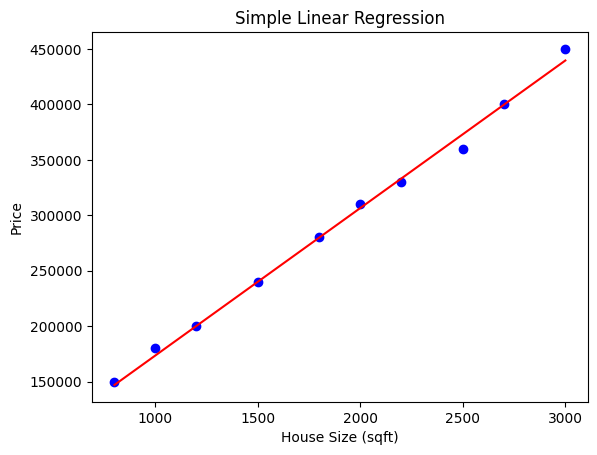

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X_simple, y, color="blue")
plt.plot(X_simple, model_simple.predict(X_simple), color="red")
plt.xlabel("House Size (sqft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()

In [10]:
X_multi = df[["size_sqft", "bedrooms"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred_multi)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_multi)

print("\nMultiple Linear Regression Results")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Multiple Linear Regression Results
MSE: 61431884.58729026
RMSE: 7837.849487409812
R2 Score: 0.9949229847448521


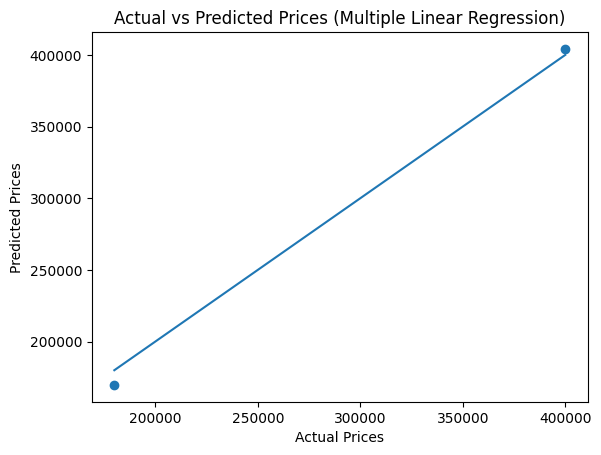

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_multi)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])  # Perfect prediction line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Multiple Linear Regression)")
plt.show()